In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## 1. Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/zkyfauzi/food-delivery-dataset/synthetic_fooddelivery_dataset.csv")

In [3]:
df.head()

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,ORD-2024-000001,2024-03-22 13:15:14,Kopi,9000,NaN,27,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
1,ORD-2024-000002,2024-01-14 17:05:37,Mie,21000,3.742238,37,NaN,NaN,False,Tidak Ada,Selesai
2,ORD-2024-000003,2024-01-04 12:32:38,Martabak,33500,12.677149,49,NaN,NaN,True,Rendah,Selesai
3,ORD-2024-000004,2024-01-26 22:34:26,Kopi,13500,2.338085,20,5.0,Mantap gan!,False,Tidak Ada,Selesai
4,ORD-2024-000005,2024-03-16 11:48:51,Ayam,47500,0.949764,27,4.0,Top bgt kualitasnya,True,Rendah,Selesai


## 2. Data Quality Assessment ( Task 1 )
### 2.1 Check Data Types

In [4]:
df.dtypes

ID_Pesanan             object
Waktu_Transaksi        object
Kategori_Menu          object
Harga_Pesanan           int64
Jarak_Kirim_KM        float64
Waktu_Tunggu_Menit      int64
Rating_Pelanggan      float64
Ulasan_Teks            object
Status_Promo             bool
Tingkat_Keluhan        object
Status_Pesanan         object
dtype: object

In [7]:
df['Waktu_Transaksi'] = pd.to_datetime(df['Waktu_Transaksi'], errors='coerce')

In [8]:
df.dtypes

ID_Pesanan                    object
Waktu_Transaksi       datetime64[ns]
Kategori_Menu                 object
Harga_Pesanan                  int64
Jarak_Kirim_KM               float64
Waktu_Tunggu_Menit             int64
Rating_Pelanggan             float64
Ulasan_Teks                   object
Status_Promo                    bool
Tingkat_Keluhan               object
Status_Pesanan                object
dtype: object

In [9]:
df['Harga_Pesanan'] = df['Harga_Pesanan'].replace(r'[\$,]', '', regex=True)

In [10]:
df['Harga_Pesanan'] = pd.to_numeric(df['Harga_Pesanan'])

In [11]:
df.dtypes

ID_Pesanan                    object
Waktu_Transaksi       datetime64[ns]
Kategori_Menu                 object
Harga_Pesanan                  int64
Jarak_Kirim_KM               float64
Waktu_Tunggu_Menit             int64
Rating_Pelanggan             float64
Ulasan_Teks                   object
Status_Promo                    bool
Tingkat_Keluhan               object
Status_Pesanan                object
dtype: object

## 3. Handling Missing Values ( Task 2 )
### 3.1 Detect Missing Values

In [13]:
df.isna()

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,True,False,False,False
2,False,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
8495,False,True,False,False,False,False,False,False,False,False,False
8496,False,True,False,False,False,False,True,True,False,False,False
8497,False,False,False,False,False,False,False,False,False,False,False
8498,False,False,False,False,False,False,True,True,False,False,False


In [14]:
df.isna().sum()

ID_Pesanan               0
Waktu_Transaksi       1630
Kategori_Menu            0
Harga_Pesanan            0
Jarak_Kirim_KM         595
Waktu_Tunggu_Menit       0
Rating_Pelanggan      1700
Ulasan_Teks           1700
Status_Promo             0
Tingkat_Keluhan          0
Status_Pesanan           0
dtype: int64

### 3.2 Demonstration: Introduce Artificial Missing Values

In [16]:
df2 = df.copy()
df2.loc[0:5, 'Harga_Pesanan'] = np.nan

In [17]:
df2.isna().sum()

ID_Pesanan               0
Waktu_Transaksi       1630
Kategori_Menu            0
Harga_Pesanan            6
Jarak_Kirim_KM         595
Waktu_Tunggu_Menit       0
Rating_Pelanggan      1700
Ulasan_Teks           1700
Status_Promo             0
Tingkat_Keluhan          0
Status_Pesanan           0
dtype: int64

Now the Harga_Pesanan column contains missing values.

In [18]:
df2.head(10)

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,ORD-2024-000001,2024-03-22 13:15:14,Kopi,NaN,NaN,27,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
1,ORD-2024-000002,2024-01-14 17:05:37,Mie,NaN,3.742238,37,NaN,NaN,False,Tidak Ada,Selesai
2,ORD-2024-000003,2024-01-04 12:32:38,Martabak,NaN,12.677149,49,NaN,NaN,True,Rendah,Selesai
3,ORD-2024-000004,2024-01-26 22:34:26,Kopi,NaN,2.338085,20,5.0,Mantap gan!,False,Tidak Ada,Selesai
4,ORD-2024-000005,2024-03-16 11:48:51,Ayam,NaN,0.949764,27,4.0,Top bgt kualitasnya,True,Rendah,Selesai
5,ORD-2024-000006,2024-02-24 12:13:48,Ayam,NaN,3.452932,13,5.0,Rekomendasi deh,True,Tidak Ada,Selesai
6,ORD-2024-000007,2024-01-12 19:54:22,Ayam,60000.0,11.643873,43,NaN,NaN,True,Tidak Ada,Selesai
7,ORD-2024-000008,2024-01-06 17:07:59,Mie,18500.0,0.585177,12,3.0,Lumayan,True,Rendah,Selesai
8,ORD-2024-000009,2024-03-11 13:36:12,Martabak,37500.0,1.183566,17,4.0,Top bgt kualitasnya,False,Tidak Ada,Dibatalkan
9,ORD-2024-000010,2024-01-06 09:05:54,Martabak,38500.0,2.341879,12,5.0,Top bgt kualitasnya,False,Tidak Ada,Dibatalkan


## Missing Value Strategy: Median Imputation
## Why??

Median imputation was applied to handle missing values in the dataset. The median was chosen instead of the mean because the dataset may contain outliers in numerical features such as price, delivery time, or distance. The median is more robust and is not affected by extreme values. Additionally, removing records was not used because it would reduce the dataset size. Therefore, median imputation provides a more reliable and accurate way to fill missing values.

In [21]:
df_median = df2.copy()
df_median['Harga_Pesanan'] = df_median['Harga_Pesanan'].fillna(df_median['Harga_Pesanan'].median())

In [22]:
df_median.head(10)

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,ORD-2024-000001,2024-03-22 13:15:14,Kopi,29000.0,NaN,27,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
1,ORD-2024-000002,2024-01-14 17:05:37,Mie,29000.0,3.742238,37,NaN,NaN,False,Tidak Ada,Selesai
2,ORD-2024-000003,2024-01-04 12:32:38,Martabak,29000.0,12.677149,49,NaN,NaN,True,Rendah,Selesai
3,ORD-2024-000004,2024-01-26 22:34:26,Kopi,29000.0,2.338085,20,5.0,Mantap gan!,False,Tidak Ada,Selesai
4,ORD-2024-000005,2024-03-16 11:48:51,Ayam,29000.0,0.949764,27,4.0,Top bgt kualitasnya,True,Rendah,Selesai
5,ORD-2024-000006,2024-02-24 12:13:48,Ayam,29000.0,3.452932,13,5.0,Rekomendasi deh,True,Tidak Ada,Selesai
6,ORD-2024-000007,2024-01-12 19:54:22,Ayam,60000.0,11.643873,43,NaN,NaN,True,Tidak Ada,Selesai
7,ORD-2024-000008,2024-01-06 17:07:59,Mie,18500.0,0.585177,12,3.0,Lumayan,True,Rendah,Selesai
8,ORD-2024-000009,2024-03-11 13:36:12,Martabak,37500.0,1.183566,17,4.0,Top bgt kualitasnya,False,Tidak Ada,Dibatalkan
9,ORD-2024-000010,2024-01-06 09:05:54,Martabak,38500.0,2.341879,12,5.0,Top bgt kualitasnya,False,Tidak Ada,Dibatalkan


## 4. Handling Outliers ( Task 3 )

In [24]:
import matplotlib.pyplot as plt

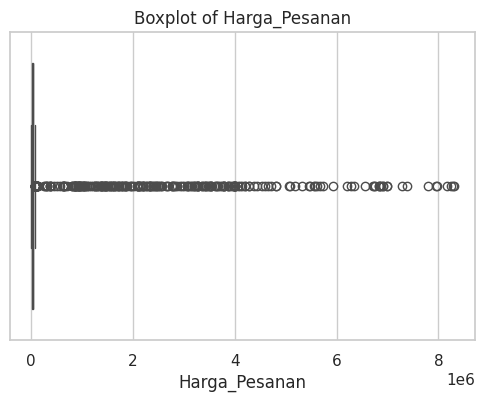

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Harga_Pesanan'])

plt.title('Boxplot of Harga_Pesanan')
plt.show()

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**


In [26]:
Q1 = df['Harga_Pesanan'].quantile(0.25)
Q3 = df['Harga_Pesanan'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Harga_Pesanan'] < lower) | (df['Harga_Pesanan'] > upper)]
outliers.head(15)

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
32,ORD-2024-000033,2024-02-26 14:07:15,Ayam,6869500,14.468625,59,3.0,Standar lah,False,Rendah,Selesai
59,ORD-2024-000060,2024-02-06 19:13:43,Ayam,3400000,9.190517,47,NaN,NaN,False,Tidak Ada,Selesai
70,ORD-2024-000071,2024-02-01 11:24:55,Martabak,2134000,0.500000,7,4.0,Nggg enak 😋,False,Tidak Ada,Selesai
82,ORD-2024-000083,NaT,Ayam,87500,14.260739,66,4.0,Enak bgt!!,True,Tidak Ada,Selesai
89,ORD-2024-000090,2024-03-04 18:41:44,Kopi,1734500,0.500000,8,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
109,ORD-2024-000110,2024-02-23 11:30:01,Ayam,89000,1.198191,20,4.0,Wow enak bgt,False,Tidak Ada,Selesai
133,ORD-2024-000134,NaT,Ayam,3602500,1.510553,20,1.0,Lama bgt nunggunya,False,Tinggi,Selesai
166,ORD-2024-000167,2024-03-11 18:53:58,Ayam,92500,5.574781,36,5.0,Wow enak bgt,False,Rendah,Selesai
191,ORD-2024-000192,2024-02-29 21:34:10,Mie,1603000,2.668507,22,3.0,Biasa saja,False,Tidak Ada,Selesai
194,ORD-2024-000195,NaT,Ayam,3533500,2.366620,28,5.0,Rekomendasi deh,False,Tinggi,Refund


### Remove Outliers


In [27]:
df_no_outliers = df[(df['Harga_Pesanan'] >= lower) & (df['Harga_Pesanan'] <= upper)]

print('df with outliers: ', df.shape)
print('df without outliers: ', df_no_outliers.shape)

df with outliers:  (8500, 11)
df without outliers:  (8190, 11)


## 5. Data Transformation – Normalization ( Task 4 )
### Min-Max Normalization

In [32]:
df[['Harga_Pesanan','Jarak_Kirim_KM']].head()

,Harga_Pesanan,Jarak_Kirim_KM
0,9000,NaN
1,21000,3.742238
2,33500,12.677149
3,13500,2.338085
4,47500,0.949764


In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Harga_Pesanan', 'Jarak_Kirim_KM']].copy()

df_scaled[['Harga_Pesanan', 'Jarak_Kirim_KM']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Harga_Pesanan,Jarak_Kirim_KM
0,0.001084,NaN
1,0.002530,0.132336
2,0.004035,0.497027
3,0.001626,0.075024
4,0.005722,0.018358


### Z-Score Normalization


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Harga_Pesanan', 'Jarak_Kirim_KM']].copy()

df_standardized[['Harga_Pesanan', 'Jarak_Kirim_KM']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Harga_Pesanan,Jarak_Kirim_KM
0,-0.181250,NaN
1,-0.160431,0.214388
2,-0.138745,3.175949
3,-0.173443,-0.251031
4,-0.114457,-0.711204


## Check Correlation Before Applying PCA


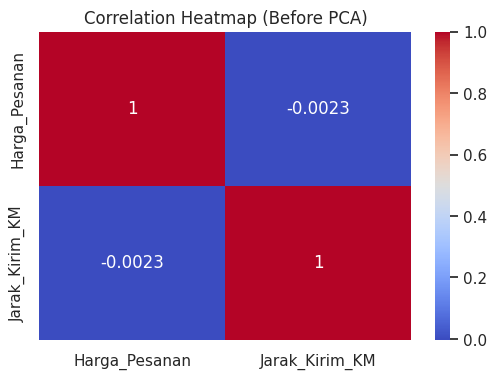

In [35]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Harga_Pesanan','Jarak_Kirim_KM']].corr(), 
            annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap (Before PCA)")
plt.show()

## 6. Data Reduction – Principal Component Analysis (PCA) ( Task 5 )

## Visual Intuition

Imagine we have two features:

X1 = Harga_Pesanan (Order Price)

X2 = Jarak_Kirim_KM (Delivery Distance)

These two features may have some relationship. PCA helps reduce them into new components that capture the most important patterns in the data while reducing dimensionality.

In [37]:
df_standardized[['Harga_Pesanan', 'Jarak_Kirim_KM']].isna().sum()

Harga_Pesanan       0
Jarak_Kirim_KM    595
dtype: int64

In [39]:
df_standardized['Jarak_Kirim_KM'] = df_standardized['Jarak_Kirim_KM'].fillna(df_standardized['Jarak_Kirim_KM'].median())

from sklearn.decomposition import PCA

X = df_standardized[['Harga_Pesanan', 'Jarak_Kirim_KM']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.51643967 0.48356033]


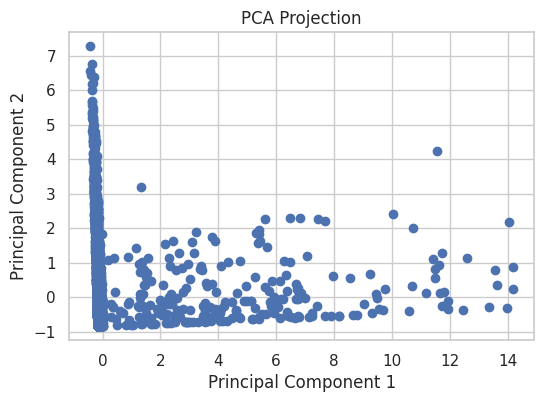

In [40]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()